In [298]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [299]:
#look at partial derivates
h = 0.000001

#fix inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h #switch between a, b, c to see how the slope changes with each
d2 = a*b + c
print('d1: ', d1)
print('d2: ', d2)
print('slope: ', (d2 - d1) / h)
#rates at which d scales with changes in a,b,c

d1:  4.0
d2:  4.000000999999999
slope:  0.9999999992515995


In [327]:
class Value:

    #children is originally tuple then stored as a set
    def __init__(self,data, _children=(), _op = '', label = ''):
        self.data = data
        self.grad = 0.0 #gradient
        self._backward = lambda: None #function to be called during backpropagation
        self._prev = set(_children)
        self._op = _op
        self._label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            #happens for addition operation as such
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad = self.data * out.grad
        out._backward = _backward

        return out

    def __pow__(self, other): # self ** other
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward

        return out

    def __rmul__(self,other): #other * self
        #e.g. 2 * a instance
        return self * other

    
    def __truediv__(self, other): # self / other
        # a/b = a * (1/b) = a * b^(-1)
        return self * other**-1

    def __neg__(self):
        return self * -1

    def __sub__(self, other): # self - other
        return self + (-other)

    def tanh(self):
        n = self.data
        t = (math.exp(2*n) - 1) / (math.exp(2*n) + 1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')

        def _backward():
            # Q) how to backpropagate through e^(f(x))? A) just f'(x) * e^f((x))
            self.grad += out.data * out.grad
        out._backward = _backward
        return out


    def backward(self):

        #implement topological sort to make sure "later" nodes are backpropagated first
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        topo
        #end up calling ._backward() on each node in reverse order of topo list

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
    

a = Value(2.0, label = 'a')
b = Value(-3.0, label = 'b')
c = Value(10.0, label = 'c')
e = a*b; e._label = 'e'
d = e+c; d._label = 'd'
f = Value(-2.0, label = 'f')
L = d*f; L._label = 'L'
L

# d._op
# d._prev

# d._prev and d._op tell us the 'children' that created the value and through what operation
# i.e. d = a*b + c
# d was made up of (a*b) and (c) through addition

Value(data=-8.0)

In [328]:
a = Value(2.0, label = 'a')
b = Value(4.0, label = 'b')
a - b



Value(data=-2.0)

In [301]:
from graphviz import Digraph

def trace(root):
    #builds nodes and edges of the graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) #left to right
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label = "{ %s | data %.4f | grad %.4f}" % (n._label, n.data, n.grad), shape='record')
        if n._op:
            #if this val is a result of some operation, create an op node for it
            dot.node(name=uid+n._op, label=n._op)
            #and connect this node to it
            dot.edge(uid+n._op, uid)

    for n1, n2 in edges:
        #connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

In [302]:
# We know dL is impacted by dd & that dd is impacted by dc
# dd/dc ?
# d = c + e
# dd/dc = 1
# by symmetry, dd/de = 1

# Chain rule: dz/dx = dz/dy * dy/dx

# Here: dL/dc = dL/dd * dd/dc
# i.e. dL/dc = -2 * -1 = -2



# dL/de = -2.0
# dL/da = dL/de * de/da
# e = a*b
# so de/da = b = -3
# dL/da = dL/de * de/da = -2 * -3 = 6



# If L = d*f
# we want dL/dd and dL/df

# dL_dd = f
# dL_df = d

# (f(x+h) - (f))/h = ((d+h)*f - d*f)/h = (d*f + h*f - d*f)/h = (h*f)/h = f

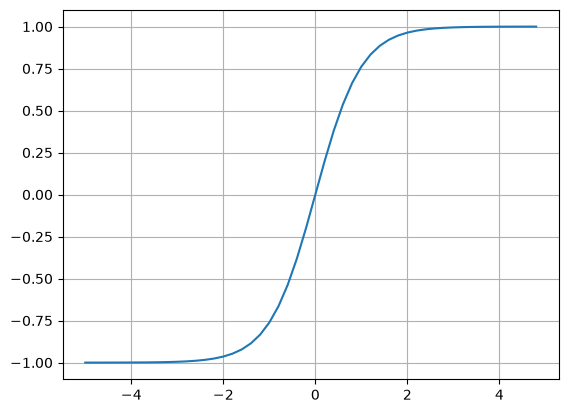

In [303]:
#backpropagate through a neuron
plt.plot(np.arange(-5,5,0.2),np.tanh(np.arange(-5,5,0.2))); plt.grid();

In [329]:
#input sx1,x2
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
#weights w1, w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
#bias of the neuron
b = Value(6.881317934523123, label = 'b')
#neuron output
x1w1 = x1*w1; x1w1._label = 'x1w1'
x2w2 = x2*w2; x2w2._label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2._label = 'x1w1x2w2'
n = x1w1x2w2 + b; n._label = 'n'
o = n.tanh(); o._label = 'o' #need to implement tanh in value class
o.backward()

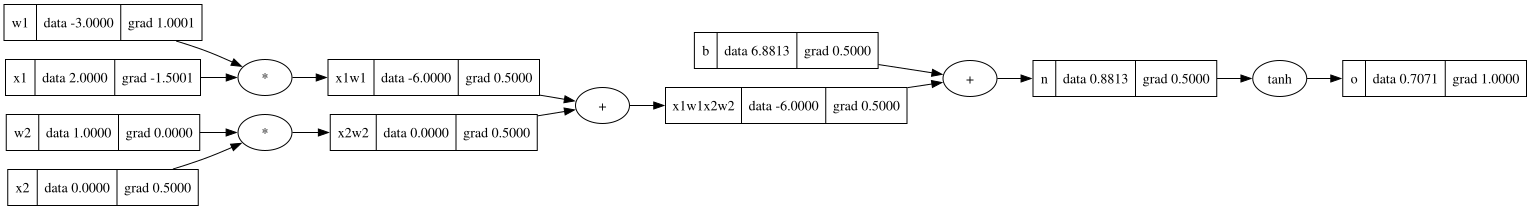

In [330]:
draw_dot(o)

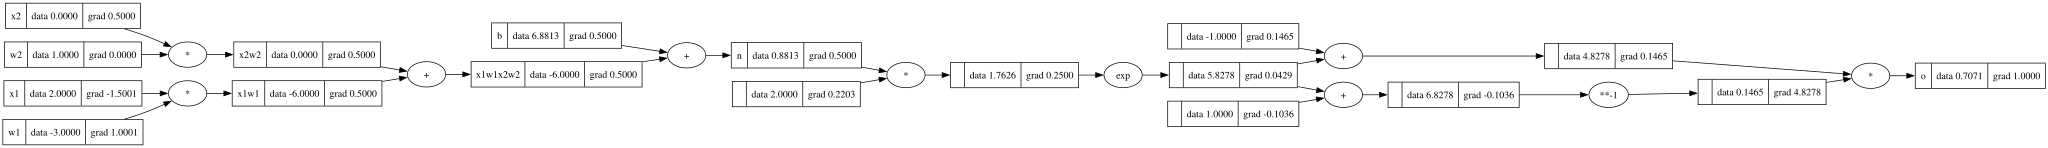

In [331]:
#input sx1,x2
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
#weights w1, w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
#bias of the neuron
b = Value(6.881317934523123, label = 'b')
#neuron output
x1w1 = x1*w1; x1w1._label = 'x1w1'
x2w2 = x2*w2; x2w2._label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2._label = 'x1w1x2w2'
n = x1w1x2w2 + b; n._label = 'n'
# ----
e = (2*n).exp()
o = (e -1) / (e + 1)
# ----
o._label = 'o' #need to implement tanh in value class
o.backward()
draw_dot(o)

In [306]:
o.grad = 1.0 #initialize the gradient of the output node
#run backpropagation to compute gradients for all nodes
# o._backward()
# n._backward()
# x1w1x2w2._backward()
# x2w2._backward()
# x1w1._backward()
o.backward()

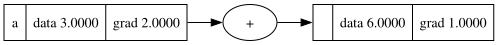

In [307]:
a = Value(3.0, label= 'a')
b = a + a ; b.label = 'b'
b.backward()
draw_dot(b)

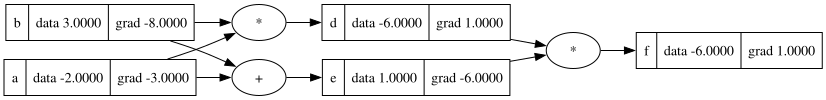

In [308]:
a = Value(-2.0, label = 'a')
b = Value(3.0, label = 'b')
d = a * b ; d._label = 'd'
e = a + b ; e._label = 'e'
f = d * e ; f._label = 'f'
f.backward()
draw_dot(f)

In [ ]:
import torch 

x1 = torch.Tensor([2.0]).double() ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double() ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double() ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double() ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double() ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('----')
print('x1', x1.grad.item())
print('x2', x2.grad.item())
print('w1', w1.grad.item())
print('w2', w2.grad.item())